# Fixed Income Concepts — Seaborn Charts

This notebook shows a handful of **simple, elegant Seaborn charts** for common fixed-income concepts, using the `fixed_income` library for the underlying calculations.

Conventions used here:
- **Yields** are in **decimal** form in computations (e.g., `0.045` = 4.5%), but plotted in **percent**.
- `Bond(T=...)` is treated as **years/periods** for labeling (no day-count conventions).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

from fixed_income import Bond, CurvePoint, NelsonSiegel, ParCurve, TreasuryParCurveSource
from fixed_income.risk import convexity, macaulay, modified, money

sns.set_theme(style="whitegrid", context="talk", palette="deep")


def pct(x: float, _pos=None) -> str:
    return f"{100.0 * float(x):.1f}%"


pct_formatter = FuncFormatter(pct)


def curve_to_df(curve: ParCurve) -> pd.DataFrame:
    df = pd.DataFrame(
        {
            "maturity_years": [p.maturity_years for p in curve.points],
            "par_yield": [p.par_yield for p in curve.points],
        }
    )
    df["par_yield_pct"] = 100.0 * df["par_yield"]
    return df


def plot_par_curve(df: pd.DataFrame, title: str) -> None:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.lineplot(data=df, x="maturity_years", y="par_yield", ax=ax, linewidth=2)
    sns.scatterplot(data=df, x="maturity_years", y="par_yield", ax=ax, s=60, zorder=3)
    ax.yaxis.set_major_formatter(pct_formatter)
    ax.set_title(title)
    ax.set_xlabel("Maturity (years)")
    ax.set_ylabel("Par yield")
    plt.tight_layout()
    plt.show()


In [ ]:
# 1) A small, deterministic synthetic par curve (offline)

synthetic_curve = ParCurve(
    as_of=pd.Timestamp("2026-01-02").date(),
    points=(
        CurvePoint(0.25, 0.0450),
        CurvePoint(0.50, 0.0455),
        CurvePoint(1.00, 0.0450),
        CurvePoint(2.00, 0.0440),
        CurvePoint(3.00, 0.0435),
        CurvePoint(5.00, 0.0438),
        CurvePoint(7.00, 0.0442),
        CurvePoint(10.0, 0.0448),
        CurvePoint(20.0, 0.0458),
        CurvePoint(30.0, 0.0463),
    ),
)

df_curve = curve_to_df(synthetic_curve)
df_curve.head()

In [ ]:
# 2) Chart: Par yield curve

plot_par_curve(df_curve, title="Synthetic par yield curve")

In [ ]:
# 3) Nelson–Siegel fit, and observed vs fitted curve

t = df_curve["maturity_years"].to_numpy(dtype=float)
r = df_curve["par_yield"].to_numpy(dtype=float)

ns = NelsonSiegel(t=t, r=r)
ns.fit(tau0=2.0)

grid = np.linspace(t.min(), t.max(), 250)
r_fit = ns.f(grid)

df_fit = pd.DataFrame({"maturity_years": grid, "par_yield": r_fit, "series": "Nelson–Siegel fit"})
df_obs = pd.DataFrame({"maturity_years": t, "par_yield": r, "series": "Observed points"})

df_both = pd.concat([df_fit, df_obs], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(
    data=df_both[df_both["series"] == "Nelson–Siegel fit"],
    x="maturity_years",
    y="par_yield",
    ax=ax,
    linewidth=2,
    label="Nelson–Siegel fit",
)
sns.scatterplot(
    data=df_both[df_both["series"] == "Observed points"],
    x="maturity_years",
    y="par_yield",
    ax=ax,
    s=60,
    label="Observed points",
    zorder=3,
)
ax.yaxis.set_major_formatter(pct_formatter)
ax.set_title("Observed points vs Nelson–Siegel fit")
ax.set_xlabel("Maturity (years)")
ax.set_ylabel("Yield")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

ns.betas, ns.tau

In [ ]:
# 4) Nelson–Siegel loadings (shape intuition)

l1, l2 = NelsonSiegel._loadings(grid, ns.tau)
df_loadings = pd.DataFrame(
    {
        "maturity_years": np.concatenate([grid, grid]),
        "loading": np.concatenate([l1, l2]),
        "loading_name": ["l1 (slope loading)"] * grid.size + ["l2 (curvature loading)"] * grid.size,
    }
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=df_loadings, x="maturity_years", y="loading", hue="loading_name", ax=ax, linewidth=2)
ax.set_title("Nelson–Siegel factor loadings")
ax.set_xlabel("Maturity (years)")
ax.set_ylabel("Loading")
ax.legend(title="")
plt.tight_layout()
plt.show()

In [ ]:
# 5) Bond price–yield curve (exact PV via fixed_income.Bond)

# A representative bond: 5% annual coupon, 10-year maturity, $100 face.
# Here, T is treated as years/periods for plotting.
bond = Bond(C=0.05, F=100.0, T=10, P=100.0)

y_grid = np.linspace(0.0, 0.10, 201)
prices = np.array([bond.f(y) for y in y_grid], dtype=float)

df_py = pd.DataFrame({"yield": y_grid, "price": prices})
df_py["yield_pct"] = 100.0 * df_py["yield"]

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=df_py, x="yield_pct", y="price", ax=ax, linewidth=2)
ax.set_title("Bond price vs yield")
ax.set_xlabel("Yield (%)")
ax.set_ylabel("Price")
plt.tight_layout()
plt.show()

In [ ]:
# 5b) Bond price evolution as time passes (pull-to-par under a flat yield)

# Interpreting "time" as whole coupon periods elapsed, and pricing *right after* a coupon payment.
# We hold yield constant (flat curve) and re-price the remaining cashflows.

bond_time = Bond(C=0.06, F=100.0, T=12, P=100.0)  # 12-year/period bond
y_hold = 0.045  # constant yield (decimal)

elapsed = np.arange(0, bond_time.T, dtype=int)
remaining = bond_time.T - elapsed
prices_time = np.array([Bond(C=bond_time.C, F=bond_time.F, T=int(tt), P=0.0).f(y_hold) for tt in remaining])

df_time = pd.DataFrame({"years_elapsed": elapsed, "years_remaining": remaining, "price": prices_time})

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=df_time, x="years_elapsed", y="price", ax=ax, linewidth=2)
sns.scatterplot(data=df_time, x="years_elapsed", y="price", ax=ax, s=60, zorder=3)
ax.set_title(f"Bond price evolution over time (flat yield = {100*y_hold:.2f}%)")
ax.set_xlabel("Years elapsed")
ax.set_ylabel("Clean price (right after coupon)")
plt.tight_layout()
plt.show()

In [ ]:
# 6) Risk measures vs yield (duration/convexity/DV01)

metrics = []
for y in y_grid:
    p = bond.f(y)
    dv01 = money(bond, ytm=y) * 1e-4  # dollars per 1bp move
    metrics.append(
        {
            "yield_pct": 100.0 * y,
            "Modified Duration": modified(bond, ytm=y),
            "Macaulay Duration": macaulay(bond, ytm=y),
            "Convexity": convexity(bond, ytm=y),
            "Price": p,
            "DV01 ($/bp)": dv01,
        }
    )

df_metrics = pd.DataFrame(metrics)

df_long = df_metrics.melt(
    id_vars=["yield_pct"],
    value_vars=["Modified Duration", "Convexity", "DV01 ($/bp)"],
    var_name="metric",
    value_name="value",
)

g = sns.relplot(
    data=df_long,
    x="yield_pct",
    y="value",
    col="metric",
    kind="line",
    col_wrap=2,
    facet_kws={"sharex": True, "sharey": False},
    height=4.0,
    aspect=1.2,
)
g.set_axis_labels("Yield (%)", "")
g.set_titles(col_template="{col_name}")
plt.tight_layout()
plt.show()

In [ ]:
# 7) Duration/convexity approximation vs exact price change

y0 = 0.04
p0 = bond.f(y0)
dmod0 = modified(bond, ytm=y0)
conv0 = convexity(bond, ytm=y0)

dy = np.linspace(-0.02, 0.02, 121)  # +/- 200bp
y_shocked = y0 + dy

p_exact = np.array([bond.f(y) for y in y_shocked], dtype=float)
p_approx = p0 * (1.0 - dmod0 * dy + 0.5 * conv0 * (dy**2))

df_approx = pd.DataFrame({"exact": p_exact, "approx": p_approx, "dy_bp": 1e4 * dy})

max_abs_err = float(np.max(np.abs(df_approx["approx"] - df_approx["exact"])))

fig, ax = plt.subplots(figsize=(7, 7))
sns.scatterplot(data=df_approx, x="exact", y="approx", ax=ax, s=40)

lo = float(min(df_approx["exact"].min(), df_approx["approx"].min()))
hi = float(max(df_approx["exact"].max(), df_approx["approx"].max()))
ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1.5, color="black", alpha=0.7)

ax.set_title("Duration+convexity approximation vs exact")
ax.set_xlabel("Exact price")
ax.set_ylabel("Approximated price")
ax.text(
    0.02,
    0.98,
    f"Base yield: {100*y0:.2f}%\nMax |error|: {max_abs_err:.4f}",
    transform=ax.transAxes,
    va="top",
    ha="left",
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.9},
)

plt.tight_layout()
plt.show()

## Optional: Pull a live US Treasury par curve

This section uses `TreasuryParCurveSource` (Treasury.gov CSV). It requires:
- `requests` installed (`pip install fixed-income[data]` or `pip install requests`)
- Internet access


In [3]:
try:
    live_curve = TreasuryParCurveSource().fetch(as_of=None)
except ImportError as e:
    print(
        "Missing optional dependency for live data. "
        "Install with: `pip install fixed-income[data]` (or `pip install requests`).\n" 
        f"Details: {e}"
    )
    live_curve = None
except Exception as e:
    print(
        "Live fetch failed (likely no internet or Treasury.gov unavailable in this environment).\n"
        f"Details: {e}"
    )
    live_curve = None

if live_curve is not None:
    df_live = curve_to_df(live_curve)
    plot_par_curve(df_live, title=f"US Treasury par curve (as of {live_curve.as_of.isoformat()})")

    t_live = df_live["maturity_years"].to_numpy(dtype=float)
    r_live = df_live["par_yield"].to_numpy(dtype=float)

    ns_live = NelsonSiegel(t=t_live, r=r_live)
    ns_live.fit(tau0=2.0)

    grid_live = np.linspace(t_live.min(), t_live.max(), 250)
    r_fit_live = ns_live.f(grid_live)

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.lineplot(x=grid_live, y=r_fit_live, ax=ax, linewidth=2, label="Nelson–Siegel fit")
    sns.scatterplot(x=t_live, y=r_live, ax=ax, s=60, label="Observed points", zorder=3)
    ax.yaxis.set_major_formatter(pct_formatter)
    ax.set_title("Treasury points vs Nelson–Siegel fit")
    ax.set_xlabel("Maturity (years)")
    ax.set_ylabel("Yield")
    ax.legend(frameon=True)
    plt.tight_layout()
    plt.show()


Live fetch failed (likely no internet or Treasury.gov unavailable in this environment).
Details: name 'TreasuryParCurveSource' is not defined


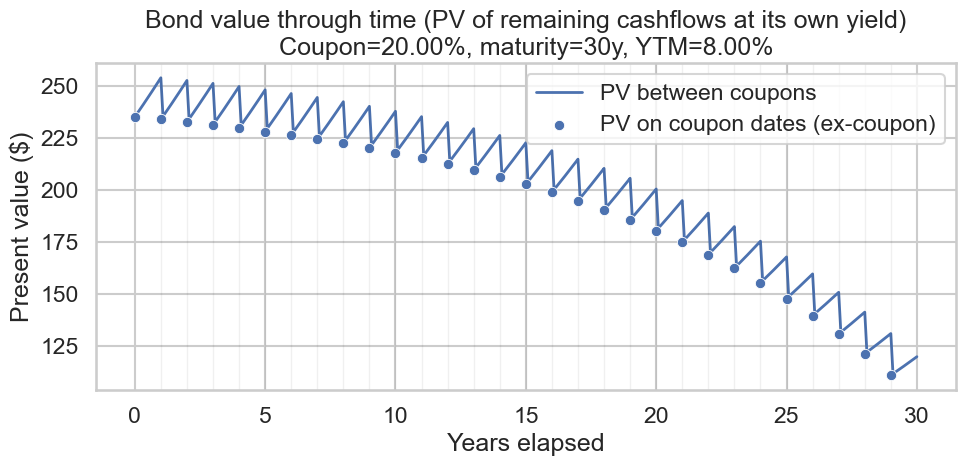

In [2]:
# 8) Bond value through time using `Bond.pv` (coupon dates + in-between)

face = 100.0
y = 0.08  # fixed yield used to set the bond's price (annual compounding)

T0 = 30
coupon_rate = 0.20

# Set P so that this bond's own YTM is exactly `y`.
P0 = float(Bond(C=coupon_rate, F=face, T=T0, P=1.0).f(y))
b = Bond(C=coupon_rate, F=face, T=T0, P=P0)
ytm = b.ytm()
assert np.isclose(ytm, y, rtol=0, atol=1e-10)

# Monthly grid (exclude maturity since pv requires t < T)
t_grid = np.linspace(0.0, T0 - 1e-9, 12 * T0 + 1)
t_int = np.floor(t_grid).astype(int)
s = t_grid - t_int

pv_grid = np.array([b.pv(t=int(tt), s=float(ss)) for tt, ss in zip(t_int, s)], dtype=float)

# Coupon dates (annual): right after each coupon payment (s=0)
t_cpn = np.arange(0, T0, 1, dtype=float)
pv_cpn = np.array([b.pv(t=int(tt), s=0.0) for tt in t_cpn], dtype=float)

df_time = pd.DataFrame({"years_elapsed": t_grid, "pv": pv_grid})
df_cpn = pd.DataFrame({"years_elapsed": t_cpn, "pv": pv_cpn})

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=df_time, x="years_elapsed", y="pv", ax=ax, linewidth=2, label="PV between coupons")
sns.scatterplot(
    data=df_cpn,
    x="years_elapsed",
    y="pv",
    ax=ax,
    s=55,
    zorder=4,
    label="PV on coupon dates (ex-coupon)",
)

for yr in range(1, T0):
    ax.axvline(yr, color="black", alpha=0.06, linewidth=1)

ax.set_title(
    "Bond value through time (PV of remaining cashflows at its own yield)\n"
    f"Coupon={100*coupon_rate:.2f}%, maturity={T0}y, YTM={100*ytm:.2f}%"
)
ax.set_xlabel("Years elapsed")
ax.set_ylabel("Present value ($)")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

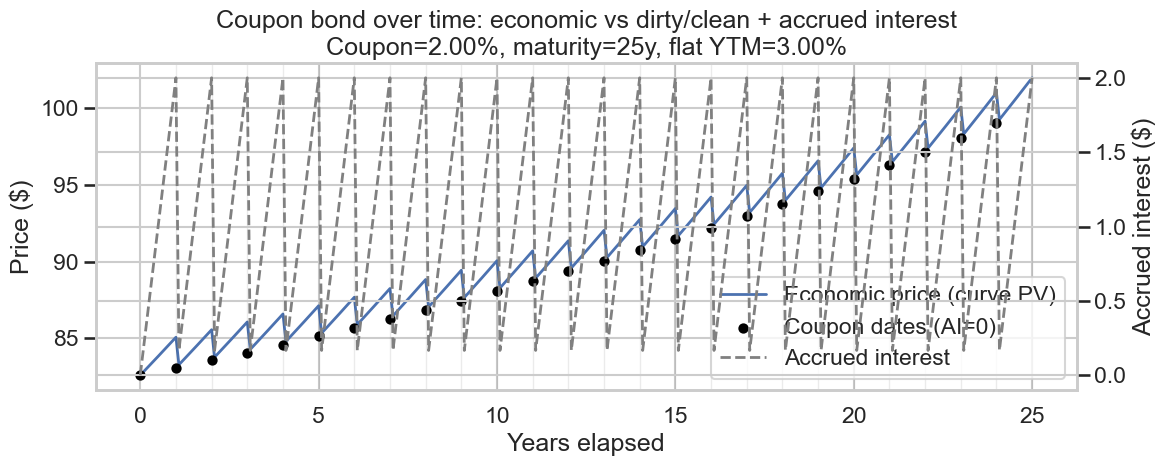

In [ ]:
# 9) Coupon bond: economic vs dirty/clean + accrued interest over time

# Pricing conventions here:
# - Annual coupons, annual compounding.
# - "Dirty" (full) price = PV of remaining cashflows at settlement.
# - Accrued interest (AI) accrues linearly within the coupon period.
# - "Clean" price = Dirty - AI.
# - "Economic" price here is just PV at a fixed yield (no curve); in this setup it matches the dirty price.

face = 100.0
coupon_rate = 0.02
T = 25  # years to maturity
y_ytm = 0.03  # quoted flat YTM (annual compounding)

coupon = coupon_rate * face


def _remaining_cashflows_at(t_elapsed_years: float):
    # Payments occur at integer years 1..T from issuance.
    # At time t_elapsed, remaining payment times are k - t_elapsed for k in (floor(t)+1 .. T).
    k_start = int(np.floor(t_elapsed_years)) + 1
    if k_start > T:
        return np.array([], dtype=float), np.array([], dtype=float)

    k = np.arange(k_start, T + 1, dtype=float)
    times = k - float(t_elapsed_years)
    cfs = np.full(times.shape, coupon, dtype=float)
    cfs[-1] += face
    return times, cfs


def dirty_price_flat_ytm(t_elapsed_years: float) -> float:
    times, cfs = _remaining_cashflows_at(t_elapsed_years)
    if times.size == 0:
        return float("nan")
    return float(np.sum(cfs / (1.0 + y_ytm) ** times))


def economic_price_fixed_yield(t_elapsed_years: float) -> float:
    return dirty_price_flat_ytm(t_elapsed_years)


def accrued_interest(t_elapsed_years: float) -> float:
    frac = float(t_elapsed_years - np.floor(t_elapsed_years))
    return float(coupon * frac)


# Sample monthly through time (exclude maturity so we always have remaining cashflows)
t_grid = np.linspace(0.0, T - 1e-6, 12 * T + 1)

dirty = np.array([dirty_price_flat_ytm(ti) for ti in t_grid], dtype=float)
econ = np.array([economic_price_fixed_yield(ti) for ti in t_grid], dtype=float)
ai = np.array([accrued_interest(ti) for ti in t_grid], dtype=float)
clean = dirty - ai

df_prices = pd.DataFrame(
    {
        "years_elapsed": t_grid,
        "Economic price (fixed yield PV)": econ,
        "Dirty price (full)": dirty,
        "Clean price (quoted)": clean,
    }
)

df_long = df_prices.melt(
    id_vars=["years_elapsed"],
    var_name="series",
    value_name="price",
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=df_long, x="years_elapsed", y="price", hue="series", ax=ax, linewidth=2)

# Mark coupon payment dates
for yr in range(1, T + 1):
    ax.axvline(yr, color="black", alpha=0.08, linewidth=1)

# Add a right axis for accrued interest (in $)
ax2 = ax.twinx()
ax2.plot(t_grid, ai, linestyle="--", linewidth=2, color="gray", label="Accrued interest")
ax2.set_ylabel("Accrued interest ($)")

# Highlight the clean/dirty coincidence at coupon dates (AI=0)
t_cpn = np.arange(0.0, float(T), 1.0)
dirty_cpn = np.array([dirty_price_flat_ytm(ti) for ti in t_cpn], dtype=float)
ax.scatter(t_cpn, dirty_cpn, s=35, color="black", zorder=5, label="Coupon dates (AI=0)")

ax.set_title(
    "Coupon bond over time: economic vs dirty/clean + accrued interest\n"
    f"Coupon={100*coupon_rate:.2f}%, maturity={T}y, flat YTM={100*y_ytm:.2f}%"
)
ax.set_xlabel("Years elapsed")
ax.set_ylabel("Price ($)")

# Build a clean combined legend
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
handles = h1 + h2
labels = l1 + l2

# De-duplicate and order legend entries
by_label = {lab: h for h, lab in zip(handles, labels)}
order = [
    "Economic price (fixed yield PV)",
    "Dirty price (full)",
    "Clean price (quoted)",
    "Coupon dates (AI=0)",
    "Accrued interest",
]
ordered_handles = [by_label[lab] for lab in order if lab in by_label]
ordered_labels = [lab for lab in order if lab in by_label]
ax.legend(ordered_handles, ordered_labels, loc="upper right", frameon=True, title="")

plt.tight_layout()
plt.show()